# Análise Exploratória e Pré-processamento de Dados  
## Fatores Associados à Busca por Tratamento de Saúde Mental em Jovens

**Nome:** Alan de Luca Tiem  
**Matrícula:** 4052025001587  
**Dataset:** Mental Health in Tech Survey

## 1. Introdução

A saúde mental tem se tornado um tema cada vez mais relevante nos últimos anos, especialmente entre jovens e adultos jovens. Questões como ansiedade, depressão, estresse e burnout vêm sendo discutidas com maior frequência tanto no ambiente acadêmico quanto profissional.

Neste trabalho, será realizada uma análise exploratória e o pré-processamento de um conjunto de dados relacionado à saúde mental de profissionais da área de tecnologia. O objetivo é investigar fatores associados à busca por tratamento em saúde mental, com atenção especial ao comportamento de indivíduos mais jovens.

A proposta contempla desde a definição do problema até a preparação dos dados, utilizando técnicas de limpeza, padronização, análise estatística e visualização de dados, conforme os conteúdos abordados na disciplina.

## 2. Definição do Problema

O presente trabalho busca responder à seguinte pergunta:

**Quais fatores estão associados à busca por tratamento de saúde mental, com foco especial em jovens?**

A análise será conduzida a partir de um dataset de pesquisa sobre saúde mental no setor de tecnologia, contendo informações demográficas, organizacionais e comportamentais.

### Tipo de problema

Este problema pode ser interpretado como um problema de **aprendizado supervisionado do tipo classificação**, pois existe uma variável-alvo (`treatment`) que indica se o indivíduo buscou ou não tratamento em saúde mental.

No entanto, neste trabalho, o foco principal será a **análise exploratória e o pré-processamento**, sem avançar para a construção de modelos preditivos.

### Premissas e hipóteses

As principais hipóteses consideradas são:

- Jovens podem apresentar comportamento diferente dos adultos em relação à busca por tratamento.
- O histórico familiar de transtornos mentais pode influenciar essa busca.
- O ambiente de trabalho pode impactar a decisão de procurar ajuda.
- Benefícios e políticas organizacionais podem facilitar o acesso ao tratamento.

### Restrições

Algumas limitações do estudo devem ser consideradas:

- O dataset representa majoritariamente profissionais da área de tecnologia.
- Os dados são autorrelatados, podendo conter vieses de percepção ou preenchimento.
- O dataset não mede diretamente o uso de medicamentos psiquiátricos, mas sim a busca por tratamento em saúde mental, que será utilizada como variável de interesse.

## 3. Importação e Leitura dos Dados

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Configuração visual
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Download do dataset
path = kagglehub.dataset_download("osmi/mental-health-in-tech-survey")

# Verificar arquivos disponíveis
print("Arquivos no diretório:", os.listdir(path))

# Selecionar automaticamente o arquivo CSV
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]

# Carregar os dados
df = pd.read_csv(f"{path}/{csv_file}")

# Visualizar primeiras linhas
df.head()

Arquivos no diretório: ['survey.csv']


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


Os dados foram obtidos a partir da plataforma Kaggle, utilizando a biblioteca `kagglehub`, que permite realizar o download automatizado do dataset.

Após o download, foi feita a identificação automática do arquivo CSV e, em seguida, o dataset foi carregado com a biblioteca `pandas`, permitindo iniciar a análise exploratória dos dados.

## 4. Tradução dos Atributos

In [122]:
# Renomear colunas para português
df.rename(columns={
    'Age': 'idade',
    'Gender': 'genero',
    'Country': 'pais',
    'state': 'estado',
    'self_employed': 'autonomo',
    'family_history': 'historico_familiar',
    'treatment': 'tratamento',
    'work_interfere': 'interferencia_trabalho',
    'no_employees': 'num_funcionarios',
    'remote_work': 'trabalho_remoto',
    'tech_company': 'empresa_tech',
    'benefits': 'beneficios',
    'care_options': 'opcoes_cuidado',
    'wellness_program': 'programa_bem_estar',
    'seek_help': 'busca_ajuda',
    'anonymity': 'anonimato',
    'leave': 'licenca',
    'mental_health_consequence': 'consequencia_saude_mental',
    'phys_health_consequence': 'consequencia_saude_fisica',
    'coworkers': 'colegas',
    'supervisor': 'supervisor',
    'mental_health_interview': 'entrevista_saude_mental',
    'phys_health_interview': 'entrevista_saude_fisica',
    'mental_vs_physical': 'mental_vs_fisico',
    'obs_consequence': 'observacoes_consequencia',
    'comments': 'comentarios'
}, inplace=True)

#Traduzir colunas
df['interferencia_trabalho'] = df['interferencia_trabalho'].replace({
    'Often': 'Frequentemente',
    'Sometimes': 'Às vezes',
    'Rarely': 'Raramente',
    'Never': 'Nunca'
})

df['beneficios'] = df['beneficios'].replace({
    'Yes': 'Sim',
    'No': 'Não',
    "Don't know": "Desconhecido"
})

df.head()

,Timestamp,idade,genero,pais,estado,autonomo,historico_familiar,tratamento,interferencia_trabalho,num_funcionarios,...,licenca,consequencia_saude_mental,consequencia_saude_fisica,colegas,supervisor,entrevista_saude_mental,entrevista_saude_fisica,mental_vs_fisico,observacoes_consequencia,comentarios
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Frequentemente,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Raramente,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Raramente,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Frequentemente,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Nunca,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


Para facilitar a compreensão do notebook e tornar a análise mais acessível, os nomes das colunas foram traduzidos para o português.

Essa etapa melhora a legibilidade do código e também contribui para a clareza na interpretação dos resultados.

## 5. Descrição dos Atributos do Dataset

A seguir, são descritos os principais atributos utilizados na análise:

- **idade**: idade do respondente.
- **genero**: gênero informado pelo respondente.
- **pais**: país de residência.
- **historico_familiar**: indica se há histórico familiar de problemas de saúde mental.
- **tratamento**: indica se o indivíduo já buscou tratamento em saúde mental.
- **interferencia_trabalho**: informa se a saúde mental interfere no trabalho.
- **num_funcionarios**: faixa de número de funcionários da empresa.
- **trabalho_remoto**: indica se o respondente trabalha remotamente.
- **empresa_tech**: indica se a empresa é da área de tecnologia.
- **beneficios**: informa se a empresa oferece benefícios relacionados à saúde mental.
- **opcoes_cuidado**: indica se existem opções de cuidado em saúde mental.
- **programa_bem_estar**: informa se a empresa possui programas de bem-estar.
- **busca_ajuda**: indica se a empresa incentiva a busca por ajuda.
- **anonimato**: informa se o anonimato é preservado ao buscar ajuda.
- **licenca**: percepção sobre a facilidade de pedir licença por questões de saúde mental.
- **consequencia_saude_mental**: percepção de consequências no trabalho ao discutir saúde mental.
- **consequencia_saude_fisica**: percepção de consequências no trabalho ao discutir saúde física.
- **colegas**: conforto para conversar com colegas sobre saúde mental.
- **supervisor**: conforto para conversar com o supervisor sobre saúde mental.

## 6. Visão Geral dos Dados

In [123]:
print("Dimensões do dataset:", df.shape)
df.info()

Dimensões do dataset: (1259, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   idade                      1259 non-null   int64 
 2   genero                     1259 non-null   object
 3   pais                       1259 non-null   object
 4   estado                     744 non-null    object
 5   autonomo                   1241 non-null   object
 6   historico_familiar         1259 non-null   object
 7   tratamento                 1259 non-null   object
 8   interferencia_trabalho     995 non-null    object
 9   num_funcionarios           1259 non-null   object
 10  trabalho_remoto            1259 non-null   object
 11  empresa_tech               1259 non-null   object
 12  beneficios                 1259 non-null   object
 13  opcoes_cuidado             125

A base de dados possui múltiplos atributos categóricos e numéricos, contendo informações pessoais e organizacionais relacionadas à saúde mental.

## 7. Primeiras Observações

In [124]:
df.head(10)

,Timestamp,idade,genero,pais,estado,autonomo,historico_familiar,tratamento,interferencia_trabalho,num_funcionarios,...,licenca,consequencia_saude_mental,consequencia_saude_fisica,colegas,supervisor,entrevista_saude_mental,entrevista_saude_fisica,mental_vs_fisico,observacoes_consequencia,comentarios
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Frequentemente,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Raramente,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Raramente,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Frequentemente,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Nunca,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN
5,2014-08-27 11:31:22,33,Male,United States,TN,NaN,Yes,No,Às vezes,6-25,...,Don't know,No,No,Yes,Yes,No,Maybe,Don't know,No,NaN
6,2014-08-27 11:31:50,35,Female,United States,MI,NaN,Yes,Yes,Às vezes,1-5,...,Somewhat difficult,Maybe,Maybe,Some of them,No,No,No,Don't know,No,NaN
7,2014-08-27 11:32:05,39,M,Canada,NaN,NaN,No,No,Nunca,1-5,...,Don't know,No,No,No,No,No,No,No,No,NaN
8,2014-08-27 11:32:39,42,Female,United States,IL,NaN,Yes,Yes,Às vezes,100-500,...,Very difficult,Maybe,No,Yes,Yes,No,Maybe,No,No,NaN
9,2014-08-27 11:32:43,23,Male,Canada,NaN,NaN,No,No,Nunca,26-100,...,Don't know,No,No,Yes,Yes,Maybe,Maybe,Yes,No,NaN


A visualização inicial das primeiras linhas do dataset permite perceber que os dados contêm tanto variáveis objetivas quanto subjetivas.

## 8. Valores Faltantes

In [125]:
df.isnull().sum().sort_values(ascending=False)

comentarios                  1095
estado                        515
interferencia_trabalho        264
autonomo                       18
genero                          0
Timestamp                       0
idade                           0
historico_familiar              0
tratamento                      0
num_funcionarios                0
pais                            0
trabalho_remoto                 0
empresa_tech                    0
opcoes_cuidado                  0
beneficios                      0
busca_ajuda                     0
anonimato                       0
licenca                         0
programa_bem_estar              0
consequencia_saude_mental       0
consequencia_saude_fisica       0
supervisor                      0
colegas                         0
entrevista_saude_mental         0
entrevista_saude_fisica         0
mental_vs_fisico                0
observacoes_consequencia        0
dtype: int64

Nesta etapa, foi verificada a existência de valores ausentes no dataset.

## 9. Estatísticas Descritivas

In [126]:
df[['idade']].describe().T

resumo_idade = pd.DataFrame({
    'minimo': [df['idade'].min()],
    'maximo': [df['idade'].max()],
    'media': [df['idade'].mean()],
    'mediana': [df['idade'].median()],
    'moda': [df['idade'].mode()[0]],
    'desvio_padrao': [df['idade'].std()],
    'valores_ausentes': [df['idade'].isnull().sum()],
    'Contagem': [df['idade'].count()],
    '25%': [df['idade'].quantile(0.25)],
    '50%': [df['idade'].quantile(0.50)],
    '75%': [df['idade'].quantile(0.75)]
}, index=['idade'])

resumo_idade

,minimo,maximo,media,mediana,moda,desvio_padrao,valores_ausentes,Contagem,25%,50%,75%
idade,-1726,99999999999,7.942815e+07,31.0,29,2.818299e+09,0,1259,27.0,31.0,36.0


As estatísticas descritivas fornecem uma visão inicial sobre o comportamento da variável numérica de idade.

## 10. Tratamento de Inconsistências

In [127]:
df[df['idade'] < 10][['idade']].head()
df[df['idade'] > 100][['idade']].head()

# Remover idades inconsistentes
df = df[(df['idade'] >= 15) & (df['idade'] <= 80)].copy()

print("Dimensões após tratamento da idade:", df.shape)

Dimensões após tratamento da idade: (1251, 27)


A variável idade apresentou valores inconsistentes e improváveis, o que sugere erros de preenchimento.

## 11. Padronização de Variáveis Categóricas

In [128]:
# Padronizar colunas binárias principais
mapeamento_sim_nao = {'Yes': 'Sim', 'No': 'Não'}

for col in ['tratamento', 'historico_familiar', 'trabalho_remoto', 'empresa_tech']:
    if col in df.columns:
        df[col] = df[col].map(mapeamento_sim_nao)

# Padronização de gênero
df['genero'] = df['genero'].astype(str).str.lower().str.strip()

masculino = ['male', 'm', 'man', 'cis male', 'male ', 'mal', 'msle', 'mail', 'maile', 'cis man']
feminino = ['female', 'f', 'woman', 'cis female', 'female ', 'femake', 'cis-female/femme', 'female (cis)']

def padronizar_genero(valor):
    if valor in masculino:
        return 'Masculino'
    elif valor in feminino:
        return 'Feminino'
    else:
        return 'Outros'

df['genero'] = df['genero'].apply(padronizar_genero)

df[['genero', 'tratamento', 'historico_familiar']].head()

,genero,tratamento,historico_familiar
0,Feminino,Sim,Não
1,Masculino,Não,Não
2,Masculino,Não,Não
3,Masculino,Sim,Sim
4,Masculino,Não,Não


Foi realizada a padronização de variáveis categóricas para garantir maior consistência na análise.

## 12. Criação de Faixa Etária

In [129]:
df['faixa_etaria'] = df['idade'].apply(lambda x: 'Jovem' if x <= 25 else 'Adulto')
df['faixa_etaria'].value_counts()

faixa_etaria
Adulto    1034
Jovem      217
Name: count, dtype: int64

Como o foco do trabalho inclui a análise de jovens, foi criada uma variável categórica chamada **faixa_etaria**.

## 13. Distribuição da Idade

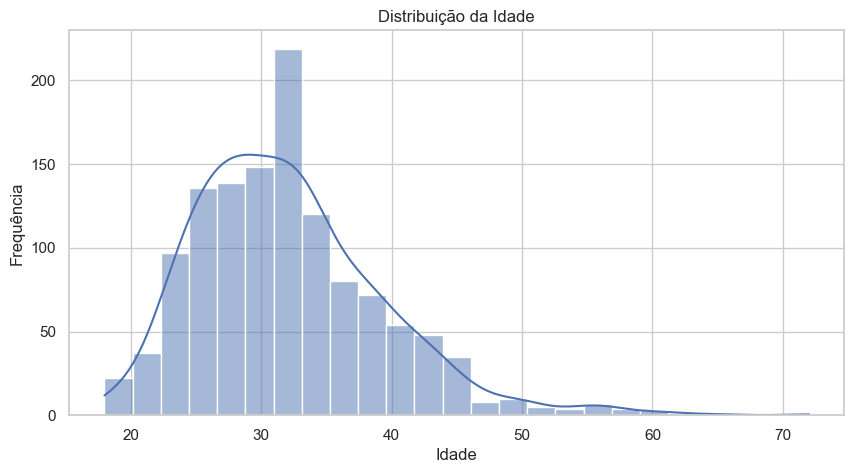

In [130]:
plt.figure(figsize=(10, 5))
sns.histplot(df['idade'], bins=25, kde=True)
plt.title('Distribuição da Idade')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

A distribuição da idade mostra maior concentração de respondentes entre aproximadamente 20 e 35 anos.

## 14. Distribuição da Busca por Tratamento

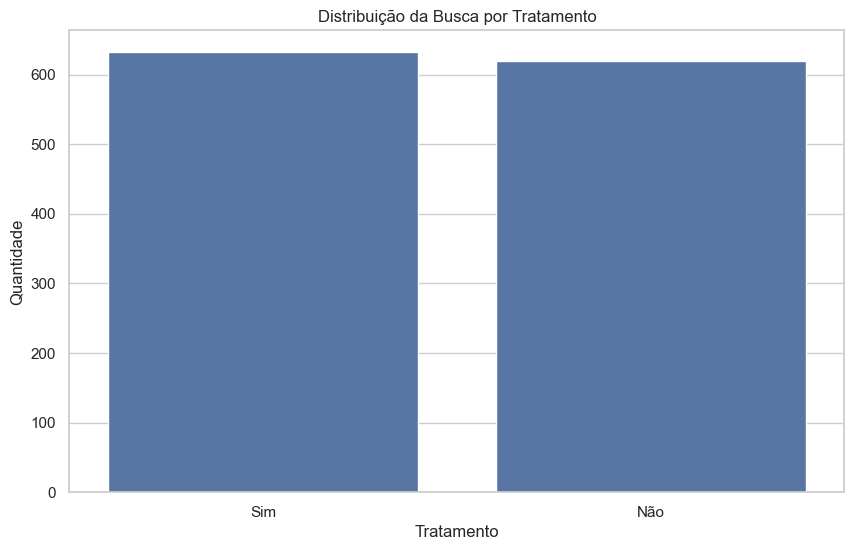

In [131]:
sns.countplot(x='tratamento', data=df)
plt.title('Distribuição da Busca por Tratamento')
plt.xlabel('Tratamento')
plt.ylabel('Quantidade')
plt.show()

A variável **tratamento** representa o principal foco da análise, indicando se o respondente já buscou ou não tratamento relacionado à saúde mental.

## 15. Comparação entre Jovens e Adultos

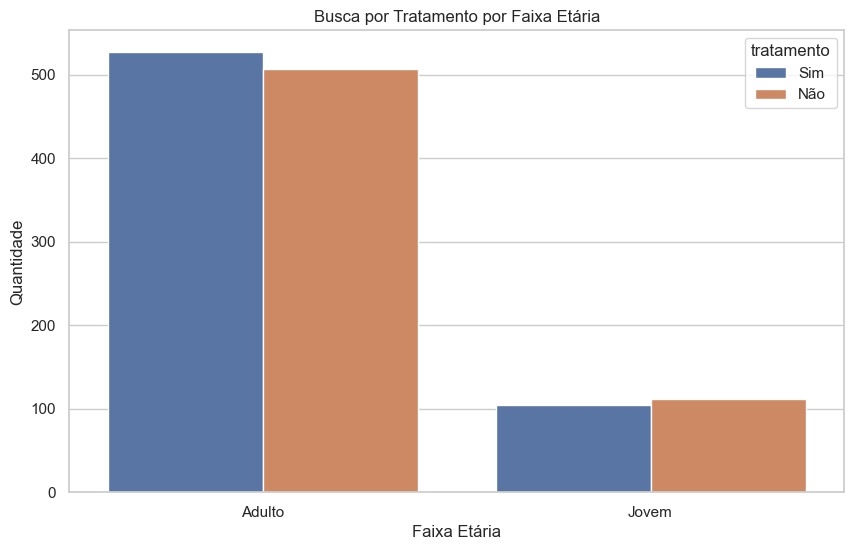

In [132]:
sns.countplot(x='faixa_etaria', hue='tratamento', data=df)
plt.title('Busca por Tratamento por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Quantidade')
plt.show()

Ao comparar jovens e adultos, é possível observar diferenças no comportamento em relação à busca por tratamento.

## 16. Taxa Proporcional de Tratamento

tratamento,Não,Sim
faixa_etaria,,
Adulto,49.032882,50.967118
Jovem,51.612903,48.387097


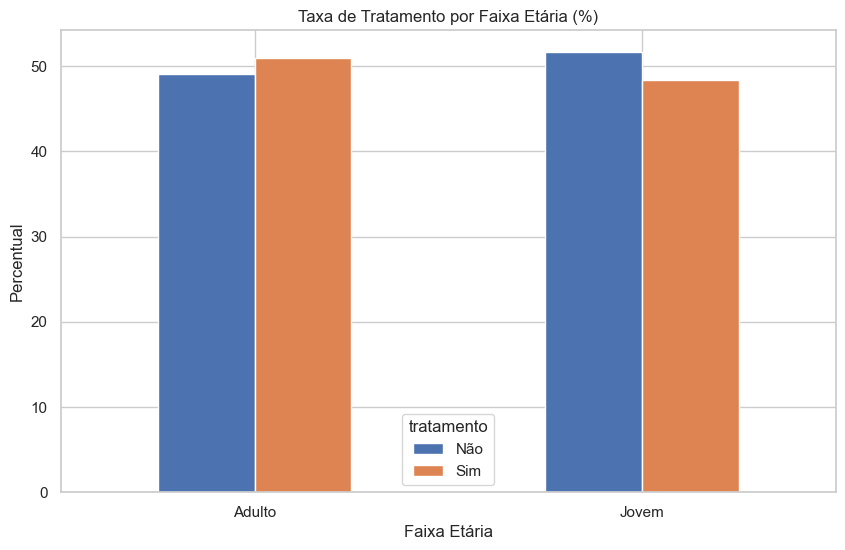

In [133]:
taxa_faixa = df.groupby('faixa_etaria')['tratamento'].value_counts(normalize=True).unstack() * 100
display(taxa_faixa)

taxa_faixa.plot(kind='bar')
plt.title('Taxa de Tratamento por Faixa Etária (%)')
plt.xlabel('Faixa Etária')
plt.ylabel('Percentual')
plt.xticks(rotation=0)
plt.show()

Além da análise por contagem, foi calculada a proporção de respondentes que buscaram tratamento dentro de cada faixa etária.

## 17. Gênero e Busca por Tratamento

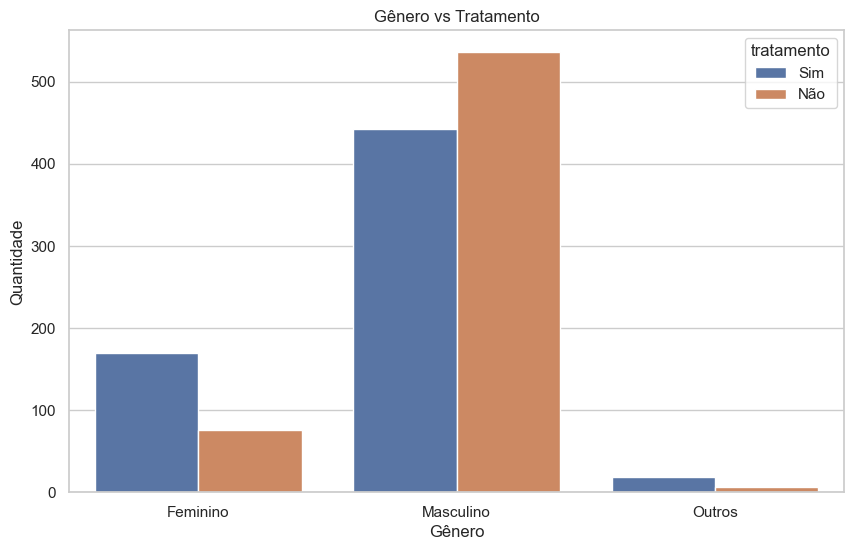

In [134]:
sns.countplot(x='genero', hue='tratamento', data=df)
plt.title('Gênero vs Tratamento')
plt.xlabel('Gênero')
plt.ylabel('Quantidade')
plt.show()

A análise da variável gênero permite investigar se existem diferenças no comportamento de busca por tratamento entre grupos.

## 18. Histórico Familiar e Busca por Tratamento

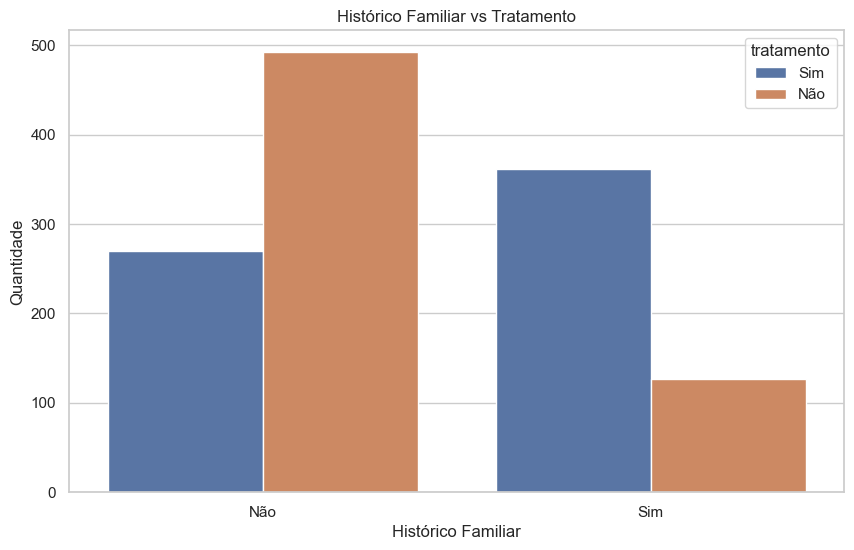

In [135]:
sns.countplot(x='historico_familiar', hue='tratamento', data=df)
plt.title('Histórico Familiar vs Tratamento')
plt.xlabel('Histórico Familiar')
plt.ylabel('Quantidade')
plt.show()

A presença de histórico familiar pode estar associada a maior percepção de risco ou maior conscientização.

## 19. Interferência da Saúde Mental no Trabalho

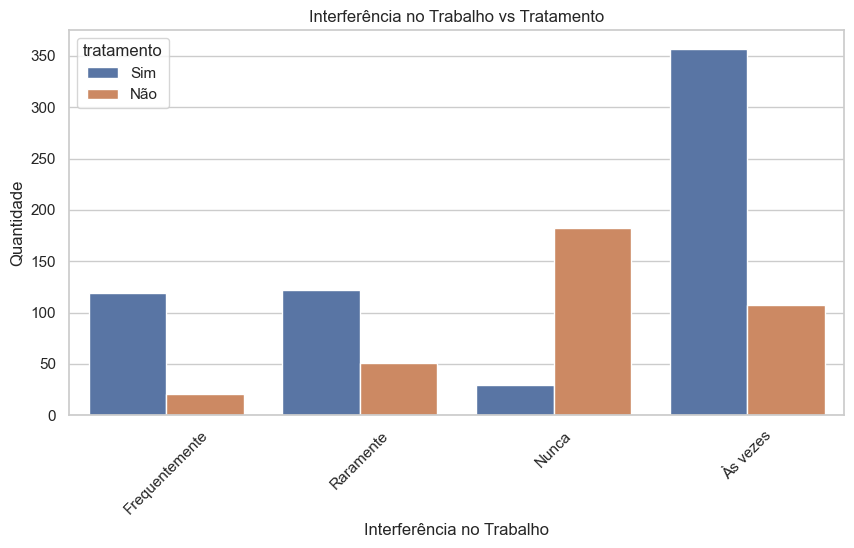

In [136]:
plt.figure(figsize=(10, 5))
sns.countplot(x='interferencia_trabalho', hue='tratamento', data=df)
plt.title('Interferência no Trabalho vs Tratamento')
plt.xlabel('Interferência no Trabalho')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.show()

Esta análise busca verificar se indivíduos que relatam impacto da saúde mental no desempenho profissional tendem a buscar mais tratamento.

## 20. Benefícios Organizacionais e Tratamento

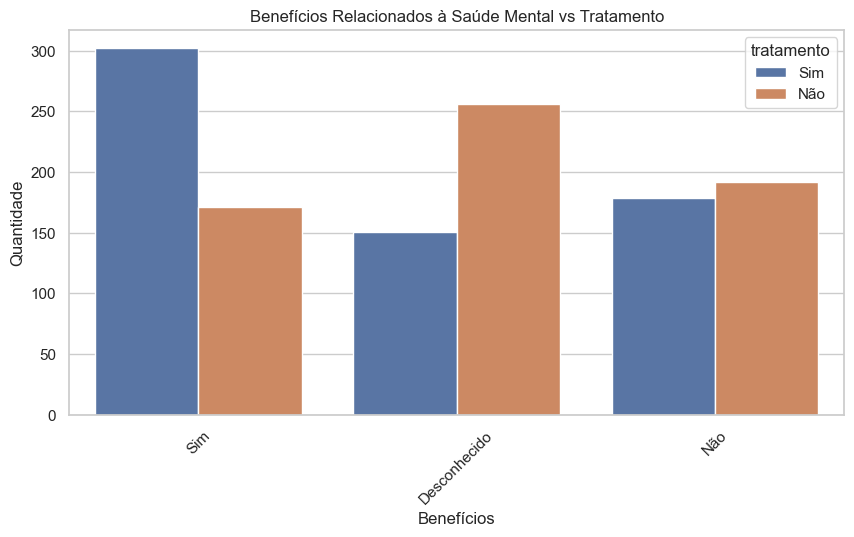

In [137]:
plt.figure(figsize=(10, 5))
sns.countplot(x='beneficios', hue='tratamento', data=df)
plt.title('Benefícios Relacionados à Saúde Mental vs Tratamento')
plt.xlabel('Benefícios')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.show()

A presença de benefícios relacionados à saúde mental pode facilitar o acesso a suporte e influenciar positivamente a decisão de buscar tratamento.

## 21. Idade e Tratamento

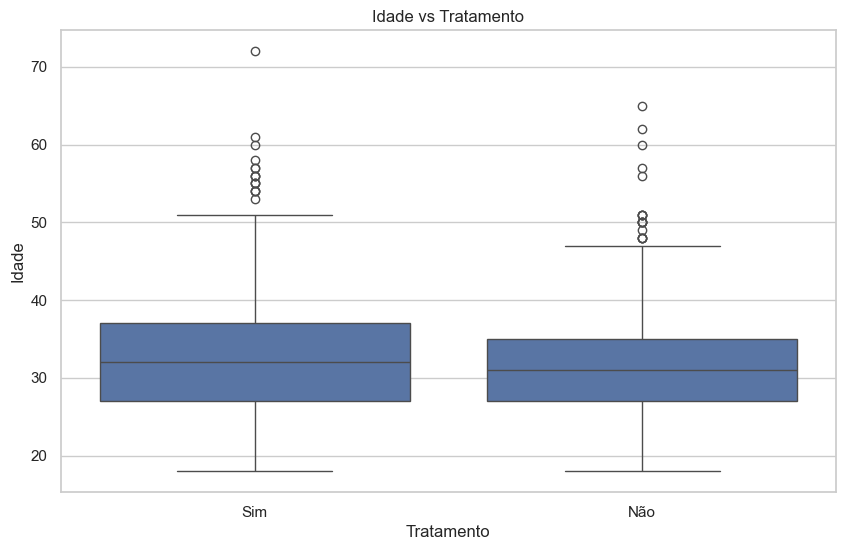

In [138]:
sns.boxplot(x='tratamento', y='idade', data=df)
plt.title('Idade vs Tratamento')
plt.xlabel('Tratamento')
plt.ylabel('Idade')
plt.show()

O boxplot permite observar a distribuição da idade entre os grupos que buscaram e não buscaram tratamento.

## 22. Principais Achados da Análise Exploratória

A análise exploratória permitiu identificar alguns padrões relevantes:

- A maior parte dos respondentes está concentrada na faixa entre 20 e 35 anos.
- Há diferenças no comportamento de busca por tratamento entre jovens e adultos.
- O histórico familiar parece estar associado à maior busca por tratamento.
- A percepção de interferência da saúde mental no trabalho também apresenta relação com a procura por ajuda.
- Fatores organizacionais, como benefícios e apoio institucional, podem influenciar o acesso ao tratamento.

Esses achados reforçam a importância de considerar tanto características individuais quanto contextuais ao analisar comportamentos relacionados à saúde mental.

## 23. Seleção de Variáveis Relevantes

In [139]:
colunas_relevantes = [
    'idade', 'genero', 'historico_familiar', 'tratamento',
    'interferencia_trabalho', 'trabalho_remoto', 'empresa_tech',
    'beneficios', 'opcoes_cuidado', 'programa_bem_estar',
    'busca_ajuda', 'anonimato', 'licenca', 'colegas',
    'supervisor', 'faixa_etaria'
]

df_modelo = df[colunas_relevantes].copy()
df_modelo.head()

,idade,genero,historico_familiar,tratamento,interferencia_trabalho,trabalho_remoto,empresa_tech,beneficios,opcoes_cuidado,programa_bem_estar,busca_ajuda,anonimato,licenca,colegas,supervisor,faixa_etaria
0,37,Feminino,Não,Sim,Frequentemente,Não,Sim,Sim,Not sure,No,Yes,Yes,Somewhat easy,Some of them,Yes,Adulto
1,44,Masculino,Não,Não,Raramente,Não,Não,Desconhecido,No,Don't know,Don't know,Don't know,Don't know,No,No,Adulto
2,32,Masculino,Não,Não,Raramente,Não,Sim,Não,No,No,No,Don't know,Somewhat difficult,Yes,Yes,Adulto
3,31,Masculino,Sim,Sim,Frequentemente,Não,Sim,Não,Yes,No,No,No,Somewhat difficult,Some of them,No,Adulto
4,31,Masculino,Não,Não,Nunca,Sim,Sim,Sim,No,Don't know,Don't know,Don't know,Don't know,Some of them,Yes,Adulto


Para a etapa de pré-processamento, foi criada uma nova visão do dataset contendo apenas os atributos considerados mais relevantes para o problema proposto.

## 24. Tratamento de Valores Faltantes

In [140]:
df_modelo.isnull().sum().sort_values(ascending=False)

# Remover registros com valores ausentes
df_modelo = df_modelo.dropna().copy()

print("Dimensões após remoção de nulos:", df_modelo.shape)

Dimensões após remoção de nulos: (989, 16)


Após a seleção das variáveis mais relevantes, foi realizada a remoção de registros com valores ausentes.

## 25. Conversão de Variáveis Binárias

In [141]:
df_modelo['tratamento'] = df_modelo['tratamento'].map({'Sim': 1, 'Não': 0})
df_modelo['historico_familiar'] = df_modelo['historico_familiar'].map({'Sim': 1, 'Não': 0})
df_modelo['trabalho_remoto'] = df_modelo['trabalho_remoto'].map({'Sim': 1, 'Não': 0})
df_modelo['empresa_tech'] = df_modelo['empresa_tech'].map({'Sim': 1, 'Não': 0})

df_modelo.head()

,idade,genero,historico_familiar,tratamento,interferencia_trabalho,trabalho_remoto,empresa_tech,beneficios,opcoes_cuidado,programa_bem_estar,busca_ajuda,anonimato,licenca,colegas,supervisor,faixa_etaria
0,37,Feminino,0,1,Frequentemente,0,1,Sim,Not sure,No,Yes,Yes,Somewhat easy,Some of them,Yes,Adulto
1,44,Masculino,0,0,Raramente,0,0,Desconhecido,No,Don't know,Don't know,Don't know,Don't know,No,No,Adulto
2,32,Masculino,0,0,Raramente,0,1,Não,No,No,No,Don't know,Somewhat difficult,Yes,Yes,Adulto
3,31,Masculino,1,1,Frequentemente,0,1,Não,Yes,No,No,No,Somewhat difficult,Some of them,No,Adulto
4,31,Masculino,0,0,Nunca,1,1,Sim,No,Don't know,Don't know,Don't know,Don't know,Some of them,Yes,Adulto


As variáveis binárias foram convertidas para formato numérico, utilizando 1 para “Sim” e 0 para “Não”.

## 26. Transformação de Variáveis Categóricas

In [142]:
df_modelo_encoded = pd.get_dummies(df_modelo, drop_first=True)
df_modelo_encoded.head()

,idade,historico_familiar,tratamento,trabalho_remoto,empresa_tech,genero_Masculino,genero_Outros,interferencia_trabalho_Nunca,interferencia_trabalho_Raramente,interferencia_trabalho_Às vezes,...,anonimato_Yes,licenca_Somewhat difficult,licenca_Somewhat easy,licenca_Very difficult,licenca_Very easy,colegas_Some of them,colegas_Yes,supervisor_Some of them,supervisor_Yes,faixa_etaria_Jovem
0,37,0,1,0,1,False,False,False,False,False,...,True,False,True,False,False,True,False,False,True,False
1,44,0,0,0,0,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,32,0,0,0,1,True,False,False,True,False,...,False,True,False,False,False,False,True,False,True,False
3,31,1,1,0,1,True,False,False,False,False,...,False,True,False,False,False,True,False,False,False,False
4,31,0,0,1,1,True,False,True,False,False,...,False,False,False,False,False,True,False,False,True,False


As variáveis categóricas foram transformadas utilizando a técnica de **One-Hot Encoding**.

## 27. Geração de Diferentes Visões do Dataset

In [143]:


# Visão com padronização (z-score)
df_padronizado = df_modelo_encoded.copy()
scaler_pad = StandardScaler()
df_padronizado[['idade']] = scaler_pad.fit_transform(df_padronizado[['idade']])

# Visão com normalização (0 a 1)
df_normalizado = df_modelo_encoded.copy()
scaler_norm = MinMaxScaler()
df_normalizado[['idade']] = scaler_norm.fit_transform(df_normalizado[['idade']])

display(df_padronizado.head())
display(df_normalizado.head())

,idade,historico_familiar,tratamento,trabalho_remoto,empresa_tech,genero_Masculino,genero_Outros,interferencia_trabalho_Nunca,interferencia_trabalho_Raramente,interferencia_trabalho_Às vezes,...,anonimato_Yes,licenca_Somewhat difficult,licenca_Somewhat easy,licenca_Very difficult,licenca_Very easy,colegas_Some of them,colegas_Yes,supervisor_Some of them,supervisor_Yes,faixa_etaria_Jovem
0,0.634844,0,1,0,1,False,False,False,False,False,...,True,False,True,False,False,True,False,False,True,False
1,1.584708,0,0,0,0,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,-0.043631,0,0,0,1,True,False,False,True,False,...,False,True,False,False,False,False,True,False,True,False
3,-0.179326,1,1,0,1,True,False,False,False,False,...,False,True,False,False,False,True,False,False,False,False
4,-0.179326,0,0,1,1,True,False,True,False,False,...,False,False,False,False,False,True,False,False,True,False


,idade,historico_familiar,tratamento,trabalho_remoto,empresa_tech,genero_Masculino,genero_Outros,interferencia_trabalho_Nunca,interferencia_trabalho_Raramente,interferencia_trabalho_Às vezes,...,anonimato_Yes,licenca_Somewhat difficult,licenca_Somewhat easy,licenca_Very difficult,licenca_Very easy,colegas_Some of them,colegas_Yes,supervisor_Some of them,supervisor_Yes,faixa_etaria_Jovem
0,0.351852,0,1,0,1,False,False,False,False,False,...,True,False,True,False,False,True,False,False,True,False
1,0.481481,0,0,0,0,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,0.259259,0,0,0,1,True,False,False,True,False,...,False,True,False,False,False,False,True,False,True,False
3,0.240741,1,1,0,1,True,False,False,False,False,...,False,True,False,False,False,True,False,False,False,False
4,0.240741,0,0,1,1,True,False,True,False,False,...,False,False,False,False,False,True,False,False,True,False


Foram geradas diferentes versões do dataset: original tratado, codificado, padronizado e normalizado.

## 28. Matriz de Correlação

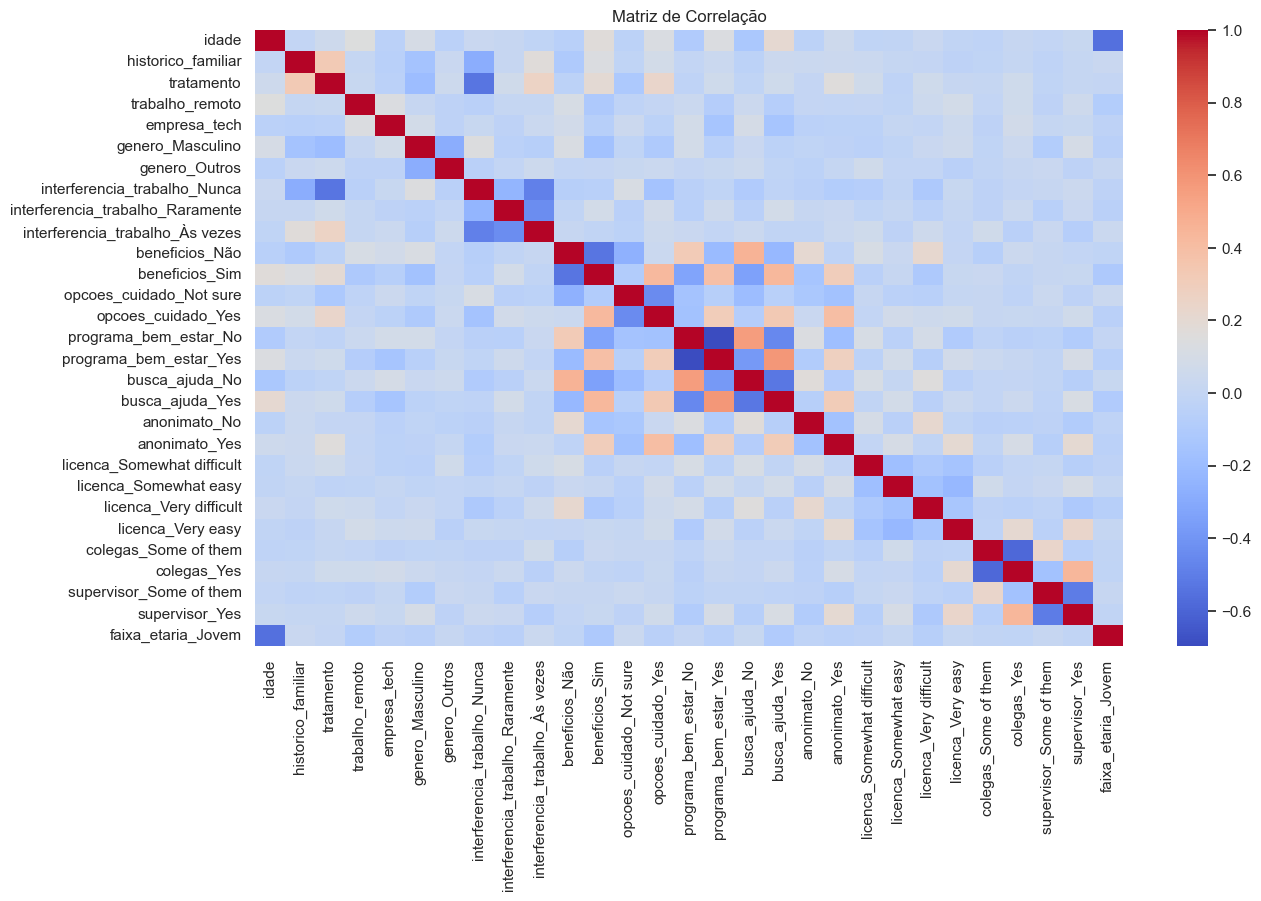

In [144]:
plt.figure(figsize=(14, 8))
sns.heatmap(df_modelo_encoded.corr(), cmap='coolwarm', annot=False)
plt.title('Matriz de Correlação')
plt.show()

A matriz de correlação permite identificar relações lineares entre as variáveis numéricas e transformadas do dataset.

## 29. Comparação entre as Visões Geradas

In [145]:
print("Dataset original tratado:", df.shape)
print("Dataset selecionado:", df_modelo.shape)
print("Dataset após encoding:", df_modelo_encoded.shape)
print("Dataset padronizado:", df_padronizado.shape)
print("Dataset normalizado:", df_normalizado.shape)

Dataset original tratado: (1251, 28)
Dataset selecionado: (989, 16)
Dataset após encoding: (989, 29)
Dataset padronizado: (989, 29)
Dataset normalizado: (989, 29)


## Hipótese 1
Pessoas com histórico familiar de problemas de saúde mental têm maior probabilidade de buscar tratamento.

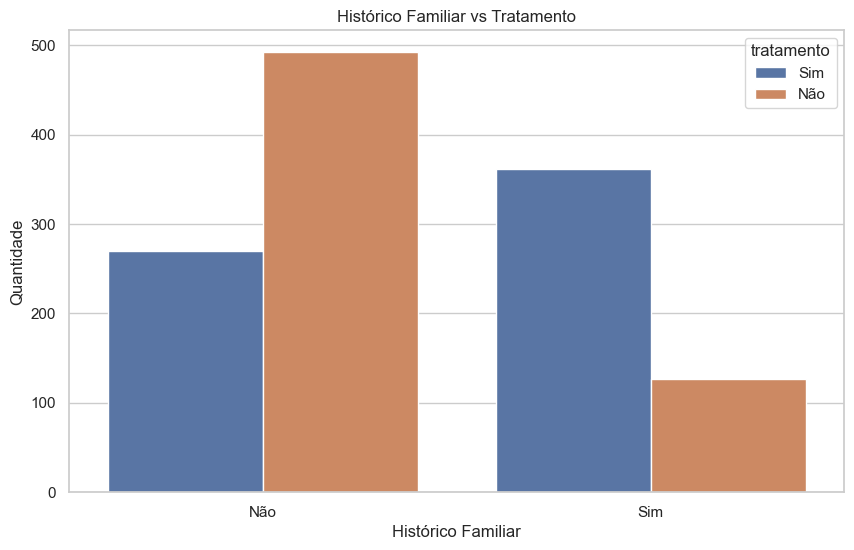

In [146]:
sns.countplot(x='historico_familiar', hue='tratamento', data=df)
plt.title('Histórico Familiar vs Tratamento')
plt.xlabel('Histórico Familiar')
plt.ylabel('Quantidade')
plt.show()

## Hipótese 2
A interferência da saúde mental no trabalho está associada a uma maior busca por tratamento.

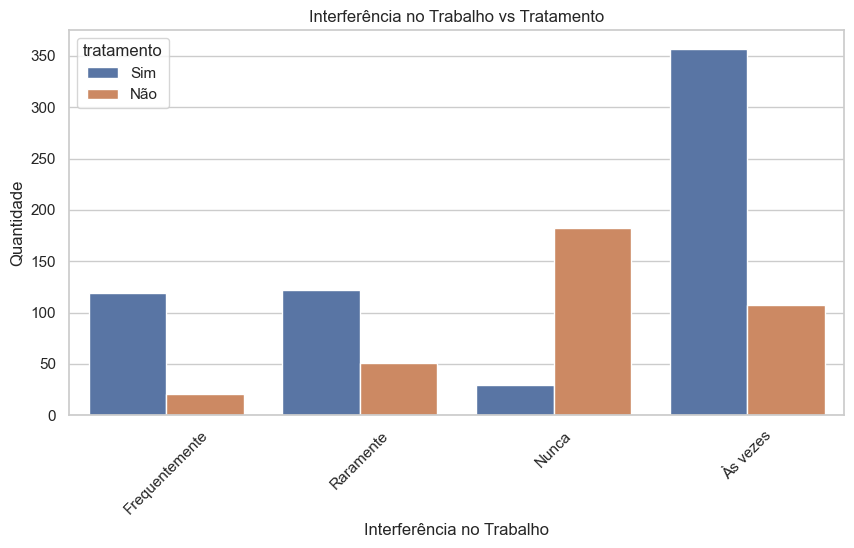

In [147]:
plt.figure(figsize=(10, 5))
sns.countplot(x='interferencia_trabalho', hue='tratamento', data=df)
plt.title('Interferência no Trabalho vs Tratamento')
plt.xlabel('Interferência no Trabalho')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.show()

## Hipótese 3
Ambientes corporativos com mais suporte (benefícios, programas de bem-estar) aumentam a probabilidade de o funcionário buscar ajuda.

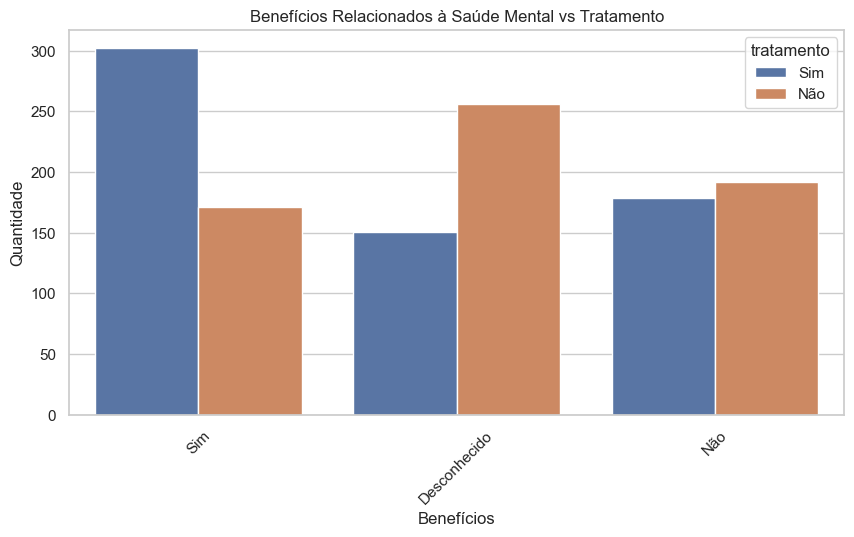

In [148]:
plt.figure(figsize=(10, 5))
sns.countplot(x='beneficios', hue='tratamento', data=df)
plt.title('Benefícios Relacionados à Saúde Mental vs Tratamento')
plt.xlabel('Benefícios')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.show()

## 30. Conclusão

Este trabalho teve como objetivo analisar fatores associados à busca por tratamento em saúde mental, com atenção especial ao comportamento de jovens.

A partir da análise exploratória, foi possível identificar padrões relevantes envolvendo idade, histórico familiar, interferência da saúde mental no trabalho e fatores organizacionais.

Além disso, foram realizadas etapas importantes de pré-processamento, como:

- tratamento de inconsistências;
- remoção de valores faltantes;
- padronização de variáveis categóricas;
- transformação de variáveis para formato numérico;
- criação de diferentes visões do dataset.

De forma geral, os resultados reforçam a importância da saúde mental como tema de análise e mostram como fatores individuais e contextuais podem influenciar a busca por tratamento.

Como possibilidade de continuidade, trabalhos futuros poderiam aplicar técnicas de aprendizado de máquina para prever a probabilidade de um indivíduo buscar tratamento, aprofundando a investigação iniciada neste estudo.